# COAD Model Report Notebook / 模型报告 Notebook

This notebook presents the latest COAD tumor vs normal model report as tables and plots, with side-by-side comparison of Logistic Regression, Random Forest, and Linear SVM.

这个 notebook 用表格和图展示最新 COAD tumor vs normal 模型报告，并横向比较 Logistic Regression（逻辑回归）、Random Forest（随机森林）和 Linear SVM（线性支持向量机）。

**Research-only caveat / 重要限制：** tumor samples come from local TCGA PanCan Atlas tables, while normal samples come from UCSC Xena Toil GTEx colon tissue. The scores may include cohort/source effects (differences caused by data source or processing / 数据来源或处理流程造成的差异), so this is not a clinical diagnostic model.


## 1. Load Artifacts / 读取结果文件

The notebook reads the generated files from `data/`, `reports/`, and `models/`. It does not retrain the models.


In [1]:
from pathlib import Path
import ast
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd() if Path.cwd().name == "coad-predictor-model" else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"

summary = json.loads((DATA_DIR / "data_summary.json").read_text(encoding="utf-8"))
metrics = pd.read_csv(REPORTS_DIR / "metrics_summary.csv")
important_genes = pd.read_csv(REPORTS_DIR / "important_genes.csv")

model_order = ["logistic_regression", "random_forest", "linear_svm"]
metrics["model"] = pd.Categorical(metrics["model"], categories=model_order, ordered=True)
metrics = metrics.sort_values("model").reset_index(drop=True)
important_genes["model"] = pd.Categorical(important_genes["model"], categories=model_order, ordered=True)
important_genes = important_genes.sort_values(["model", "rank"]).reset_index(drop=True)

summary, metrics.shape, important_genes.shape


({'tumor_samples': 449,
  'normal_samples': 308,
  'shared_genes': 18214,
  'tumor_source': 'bio_tcga.matrix_rnaseq_gene_expression',
  'normal_source': 'toil_gtex_colon_normal.expression_log2_tpm',
  'notes': ['Tumor data comes from local TCGA PanCan Atlas tables; normal data comes from UCSC Xena Toil GTEx colon samples.',
   'GTEx normal values were converted from Xena log2 TPM scale back to linear expression before the shared preprocessing log2(x+1) step.',
   'Tumor and normal expression data still come from different cohorts, so source/cohort effects remain possible.',
   'Raw database tables and source files are not modified.',
   'Only shared gene symbols are used.']},
 (3, 15),
 (90, 6))

## 2. Dataset Summary / 数据集概况

This section shows how many tumor and normal samples were used. A more balanced dataset makes evaluation more reliable than the old 449 tumor vs 41 normal version.


In [2]:
dataset_table = pd.DataFrame([
    {"item": "Tumor samples", "value": summary.get("tumor_samples")},
    {"item": "Normal samples", "value": summary.get("normal_samples")},
    {"item": "Shared genes before filtering", "value": summary.get("shared_genes")},
    {"item": "Tumor source", "value": summary.get("tumor_source")},
    {"item": "Normal source", "value": summary.get("normal_source")},
])
display(dataset_table)

notes = summary.get("notes", [])
display(Markdown("\n".join(f"- {note}" for note in notes)))


,item,value
0,Tumor samples,449
1,Normal samples,308
2,Shared genes before filtering,18214
3,Tumor source,bio_tcga.matrix_rnaseq_gene_expression
4,Normal source,toil_gtex_colon_normal.expression_log2_tpm


- Tumor data comes from local TCGA PanCan Atlas tables; normal data comes from UCSC Xena Toil GTEx colon samples.
- GTEx normal values were converted from Xena log2 TPM scale back to linear expression before the shared preprocessing log2(x+1) step.
- Tumor and normal expression data still come from different cohorts, so source/cohort effects remain possible.
- Raw database tables and source files are not modified.
- Only shared gene symbols are used.

## 3. Model Metrics Comparison / 模型指标对比

`accuracy` means total correctness. `balanced_accuracy` is safer when classes are not perfectly balanced. `recall` means how many true samples from one class were found by the model.


In [3]:
metric_cols = [
    "model", "accuracy", "balanced_accuracy", "roc_auc", "pr_auc",
    "normal_precision", "normal_recall", "normal_f1", "normal_support",
    "tumor_precision", "tumor_recall", "tumor_f1", "tumor_support",
]
comparison = metrics[metric_cols].copy()
for col in comparison.select_dtypes(include="number").columns:
    if not col.endswith("support"):
        comparison[col] = comparison[col].round(4)
display(comparison)


,model,accuracy,balanced_accuracy,roc_auc,pr_auc,normal_precision,normal_recall,normal_f1,normal_support,tumor_precision,tumor_recall,tumor_f1,tumor_support
0,logistic_regression,1.0,1.0,1.0,1.0,1.0,1.0,1.0,62,1.0,1.0,1.0,90
1,random_forest,1.0,1.0,1.0,1.0,1.0,1.0,1.0,62,1.0,1.0,1.0,90
2,linear_svm,1.0,1.0,1.0,1.0,1.0,1.0,1.0,62,1.0,1.0,1.0,90


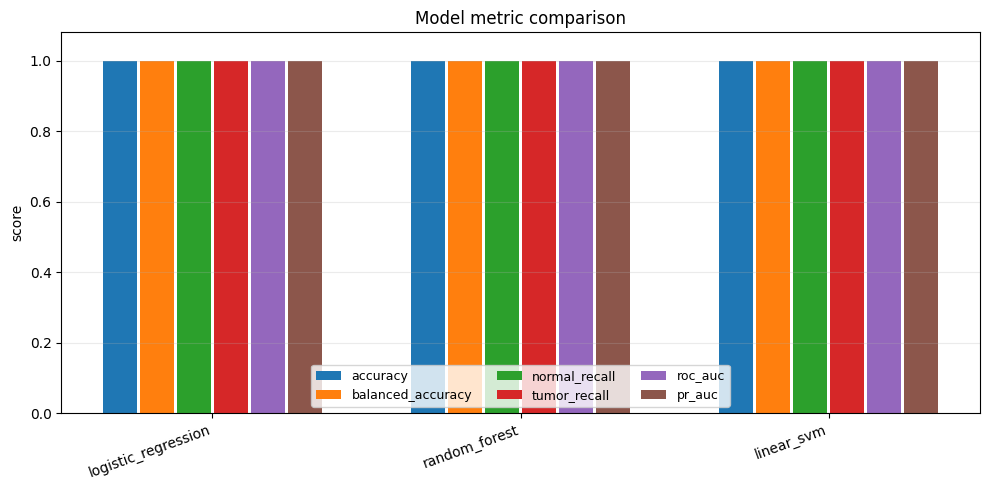

In [4]:
plot_metrics = ["accuracy", "balanced_accuracy", "normal_recall", "tumor_recall", "roc_auc", "pr_auc"]
plot_df = metrics[["model", *plot_metrics]].melt(id_vars="model", var_name="metric", value_name="score")

fig, ax = plt.subplots(figsize=(10, 5))
for i, metric in enumerate(plot_metrics):
    subset = plot_df[plot_df["metric"] == metric]
    positions = np.arange(len(model_order)) + (i - (len(plot_metrics)-1)/2) * 0.12
    ax.bar(positions, subset["score"], width=0.11, label=metric)
ax.set_xticks(np.arange(len(model_order)), model_order, rotation=20, ha="right")
ax.set_ylim(0, 1.08)
ax.set_ylabel("score")
ax.set_title("Model metric comparison")
ax.legend(ncol=3, fontsize=9)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 4. Confusion Matrices / 混淆矩阵

A confusion matrix compares true labels and predicted labels. Perfect prediction has values only on the diagonal.


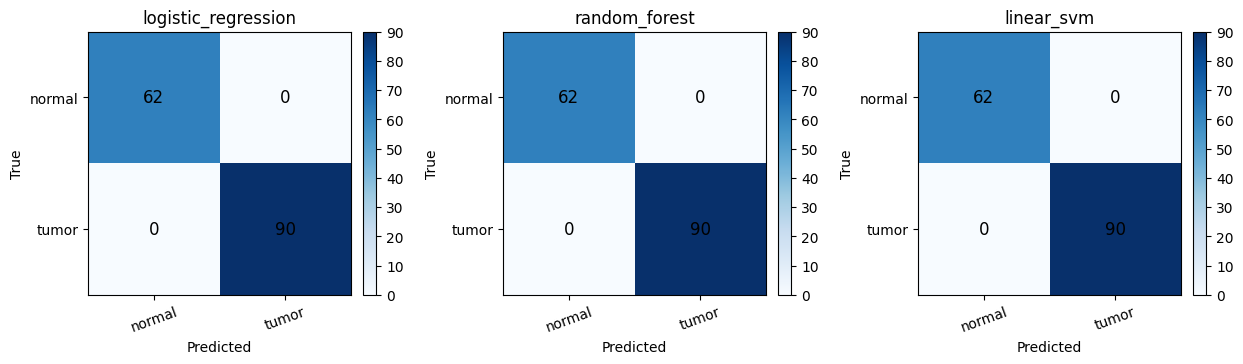

In [5]:
fig, axes = plt.subplots(1, len(metrics), figsize=(4.2 * len(metrics), 3.6))
if len(metrics) == 1:
    axes = [axes]
labels = ["normal", "tumor"]
for ax, (_, row) in zip(axes, metrics.iterrows()):
    cm = np.array(ast.literal_eval(row["confusion_matrix"]))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(str(row["model"]))
    ax.set_xticks(range(len(labels)), labels, rotation=20)
    ax.set_yticks(range(len(labels)), labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black", fontsize=12)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 5. ROC And PR Curves / ROC 与 PR 曲线

ROC curve and Precision-Recall curve show how well a model separates tumor from normal across score thresholds. PR curve is especially useful when labels are imbalanced.


### ROC curve

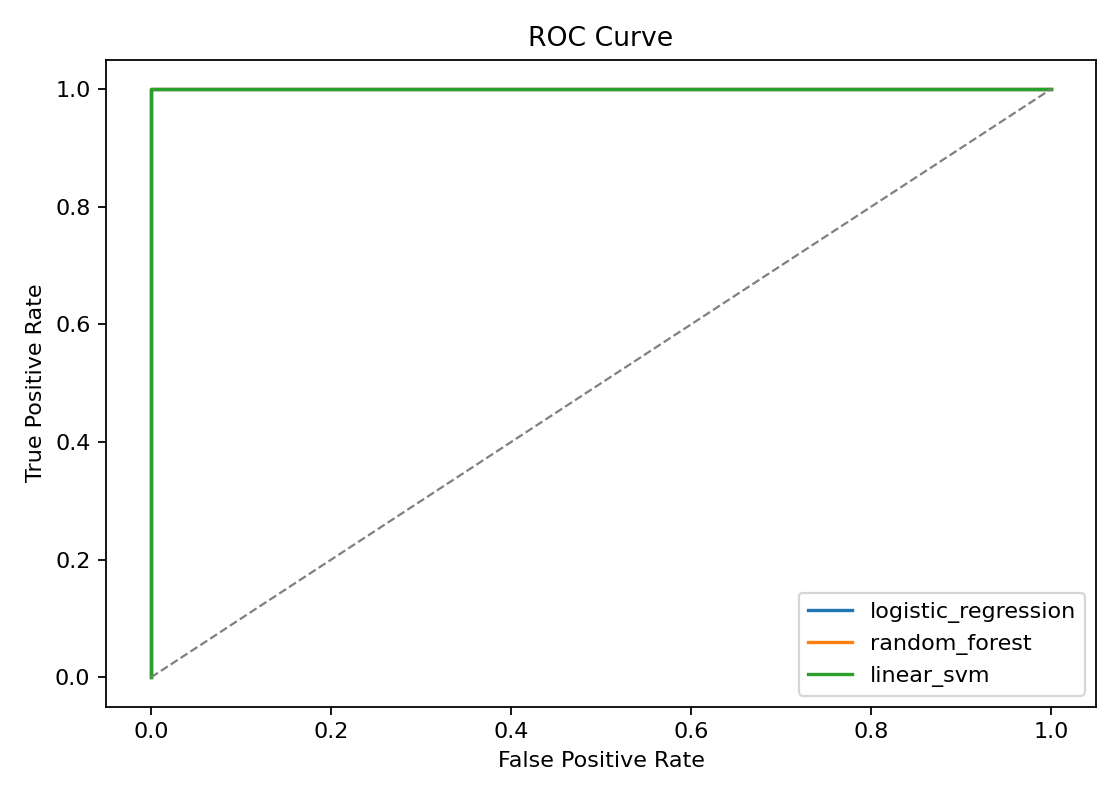

### Precision-Recall curve

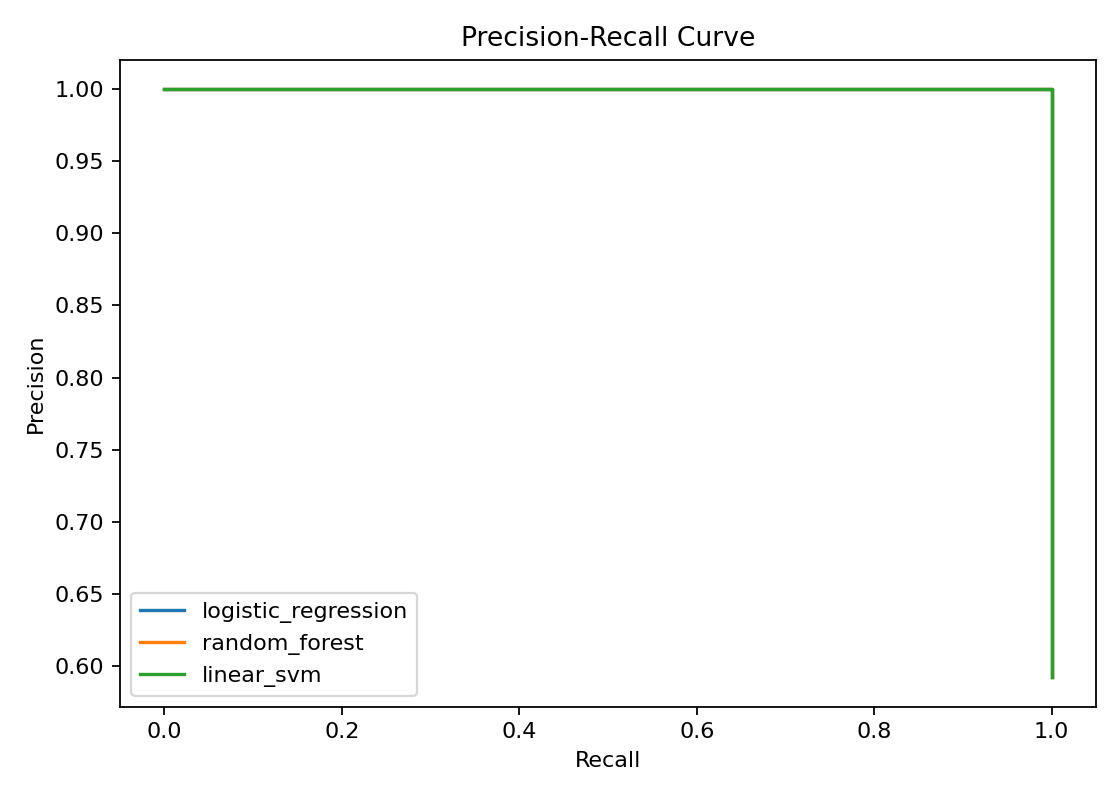

In [6]:
for filename, title in [("roc_curve.png", "ROC curve"), ("pr_curve.png", "Precision-Recall curve")]:
    path = REPORTS_DIR / filename
    if path.exists():
        display(Markdown(f"### {title}"))
        display(Image(filename=str(path)))
    else:
        print(f"Missing {path}")


## 6. Important Gene Comparison / 重要基因对比

These genes are predictive features, not proven cancer-causing genes. Use them as candidates for literature review.


In [7]:
top_n = 10
top_genes = important_genes.groupby("model", observed=True).head(top_n)[[
    "model", "rank", "gene_symbol", "importance_score", "direction"
]].copy()
top_genes["importance_score"] = top_genes["importance_score"].round(6)
display(top_genes)


,model,rank,gene_symbol,importance_score,direction
0,logistic_regression,1,EIF3IP1,0.001641,higher_tumor_score
1,logistic_regression,2,SLC5A10,0.001465,higher_tumor_score
2,logistic_regression,3,POTEF,0.001453,higher_tumor_score
3,logistic_regression,4,IGLL1,0.001447,higher_tumor_score
4,logistic_regression,5,EFCAB10,0.001444,higher_tumor_score
5,logistic_regression,6,CRIPAK,0.001439,higher_tumor_score
6,logistic_regression,7,MRPL2,0.001422,higher_tumor_score
7,logistic_regression,8,RPS2P32,0.001413,higher_tumor_score
8,logistic_regression,9,RPLP0P2,0.001410,higher_tumor_score
9,logistic_regression,10,CHRNA10,0.001402,higher_tumor_score


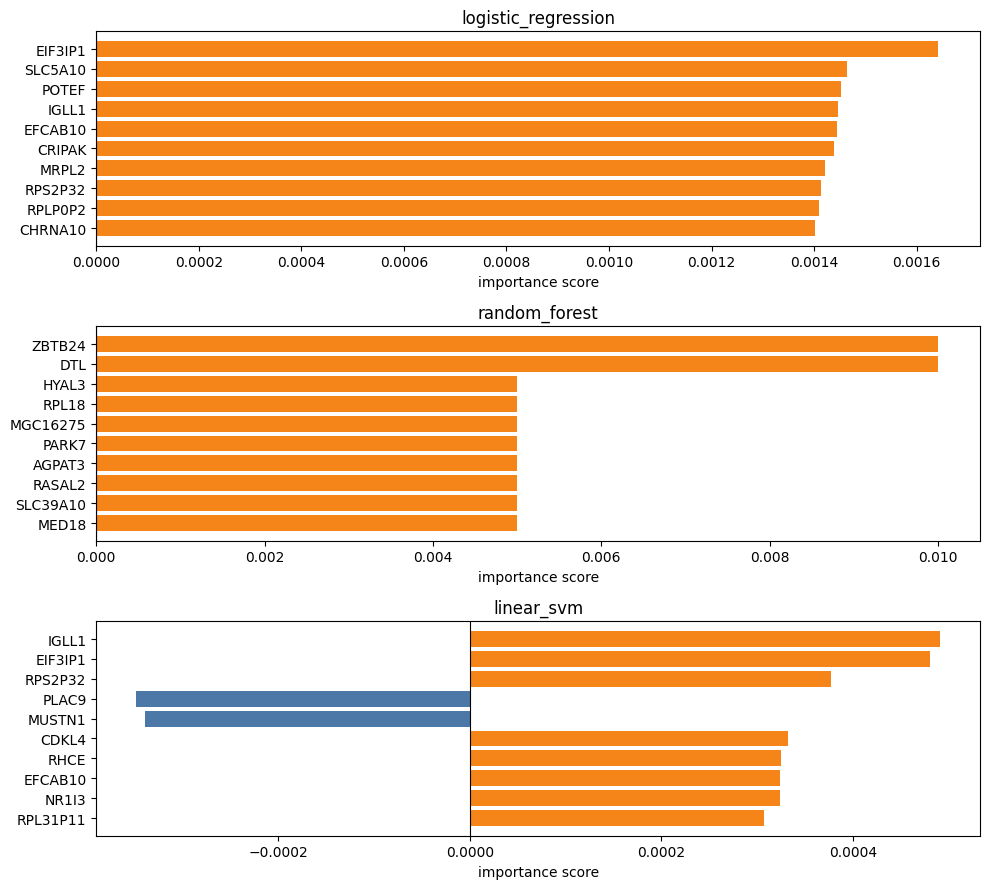

In [8]:
fig, axes = plt.subplots(len(model_order), 1, figsize=(10, 9), sharex=False)
for ax, model in zip(axes, model_order):
    subset = important_genes[important_genes["model"] == model].head(10).copy()
    subset = subset.iloc[::-1]
    colors = np.where(subset["direction"].astype(str).str.contains("normal"), "#4C78A8", "#F58518")
    ax.barh(subset["gene_symbol"], subset["importance_score"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(model)
    ax.set_xlabel("importance score")
plt.tight_layout()
plt.show()


In [9]:
gene_sets = {
    model: set(important_genes[important_genes["model"] == model].head(30)["gene_symbol"])
    for model in model_order
}
overlap_rows = []
for left in model_order:
    for right in model_order:
        overlap_rows.append({
            "model_a": left,
            "model_b": right,
            "top30_overlap_genes": len(gene_sets[left] & gene_sets[right]),
        })
overlap = pd.DataFrame(overlap_rows).pivot(index="model_a", columns="model_b", values="top30_overlap_genes")
display(overlap)


model_b,linear_svm,logistic_regression,random_forest
model_a,,,
linear_svm,30,8,0
logistic_regression,8,30,0
random_forest,0,0,30


## 7. Model Comparison Summary / 模型对比总结

All three models reach perfect test-set metrics on this split. This looks impressive, but it is also a warning sign: TCGA tumor and GTEx normal samples may be easier to separate because they come from different cohorts and processing histories.

三个模型在这次测试集上都是满分。这个结果看起来很好，但也提醒我们要小心：TCGA tumor 和 GTEx normal 来自不同来源，模型可能学到了一部分 source/cohort effect（来源或队列差异），不一定全是 cancer biology（癌症生物学）。

Recommended next step: use Toil-reprocessed TCGA tumor together with GTEx normal, or test on an independent dataset, before making stronger scientific claims.
